# 03. 線形写像・行列式・固有値 — 方向が変わらない特別な軸

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 10. Exercises |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

行列を「1 回掛ける」だけでなく「何度も掛け続ける」と、新しい問いが生まれます。
**長期的に何が起きるのか?** 答えの鍵が **固有ベクトル** です。

- 固有ベクトル: 変換しても **方向が変わらない** 特別な軸
- 固有値: その軸方向の **伸び縮みの倍率**
- 対角化: 固有ベクトルの軸で見れば、複雑な行列もただの「軸ごとの伸縮」になる

「良い座標軸を選べば、変換は劇的に単純になる」— これがこの章のメッセージであり、
05 章の SVD・PCA、07 章の量子力学まで一直線につながります。

```{admonition} 核心 — ひとことで
:class: tip
**固有ベクトルとは「変換しても向きが変わらない軸」、固有値はその軸の伸縮率である。**
良い座標（固有ベクトルの軸）から見れば、複雑な行列もただの「軸ごとの伸び縮み」$D=\mathrm{diag}(\lambda_i)$ に化ける。
だから $A$ を何度掛けても $A^k = P D^k P^{-1}$ で一撃で求まり、
**最大の $|\lambda|$ を持つ方向が長期挙動を支配する。**
```

## 2. Problem — 引っ越しの長期予測

2 つの都市 A, B の間で、毎年人口が移動します。

- A の住民の 90% は残留、10% が B へ
- B の住民の 20% が A へ、80% は残留

今年の人口を $(a, b)$ とすると、来年の人口は:

$$
\begin{pmatrix} a' \\ b' \end{pmatrix}
=
\begin{pmatrix} 0.9 & 0.2 \\ 0.1 & 0.8 \end{pmatrix}
\begin{pmatrix} a \\ b \end{pmatrix}
$$

**問い: 100 年後の人口比はどうなるか?** 行列を 100 回掛ければ計算はできますが、
「なぜその比率に落ち着くのか」「初期値によらないのか」に答えるには、
この行列の **固有ベクトル** を見る必要があります。

In [1]:
# Shared setup.
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from la_book import algebra, plotting

np.set_printoptions(precision=4, suppress=True)

P = np.array([[0.9, 0.2],
              [0.1, 0.8]])  # migration matrix (columns: where A/B residents go)

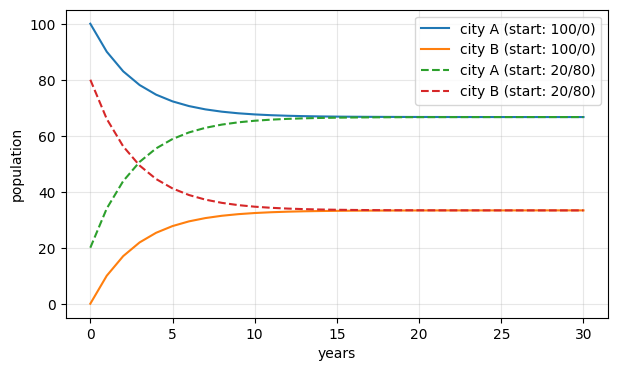

after 30 years: [66.6674 33.3326] [66.6656 33.3344]


In [2]:
# Brute force: apply P repeatedly to two different initial populations.
x1 = np.array([100.0, 0.0])    # everyone starts in city A
x2 = np.array([20.0, 80.0])    # most start in city B

traj1, traj2 = [x1], [x2]
for _ in range(30):
    traj1.append(P @ traj1[-1])
    traj2.append(P @ traj2[-1])
traj1, traj2 = np.array(traj1), np.array(traj2)

plt.figure(figsize=(7, 4))
plt.plot(traj1[:, 0], label="city A (start: 100/0)")
plt.plot(traj1[:, 1], label="city B (start: 100/0)")
plt.plot(traj2[:, 0], "--", label="city A (start: 20/80)")
plt.plot(traj2[:, 1], "--", label="city B (start: 20/80)")
plt.xlabel("years"); plt.ylabel("population")
plt.grid(alpha=0.3); plt.legend()
plt.show()
print("after 30 years:", traj1[-1], traj2[-1])

どちらの初期値から始めても、人口比は同じ **2 : 1** に収束しました。
この「収束先の方向」と「収束の速さ」を説明するのが固有値・固有ベクトルです。

## 3. Intuition — 方向が変わらない軸を探す

行列 $A$ を掛けると、ほとんどのベクトルは **向きを変えられて** しまいます。
しかし特別な方向のベクトルだけは、向きそのままで **伸び縮みだけ** されます。

$$
A v = \lambda v
$$

- $v$(固有ベクトル): 変換に「逆らわない」方向
- $\lambda$(固有値): その方向の伸縮倍率

たとえるなら、回転ドアの回転軸、布を引っ張ったときの繊維の方向です。
$A$ を何度も掛けるとき、固有ベクトル方向の成分は $\lambda^k$ 倍されるだけなので、
**最大の $|\lambda|$ を持つ方向が長期挙動を支配** します。

## 4. Visualization — 固有ベクトル方向だけが保存される

単位円上のあらゆる方向 $u$ について、$u$(灰色)と $Au$(矢印)を重ねて描きます。
ほとんどの方向で $Au$ は $u$ からずれますが、**赤い矢印** の方向だけは
$u$ と平行のまま — それが固有ベクトル方向です。

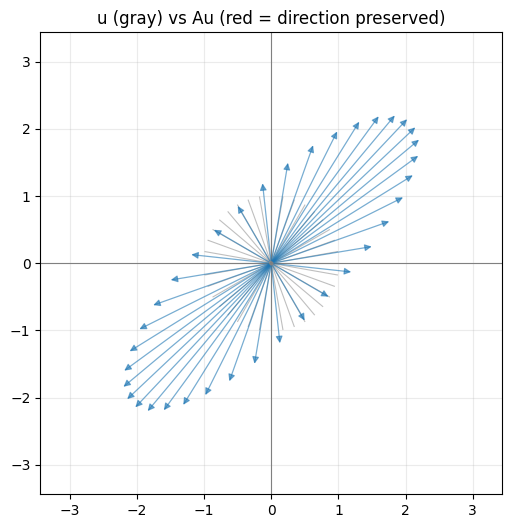

eigenvalues: [3. 1.]
eigenvectors (columns):
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]


In [3]:
# Directions u (gray) vs A u (arrows); red arrows keep their direction = eigenvectors.
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])
plotting.plot_direction_field(A)
plt.show()

w, V = np.linalg.eig(A)
print("eigenvalues:", w)
print("eigenvectors (columns):\n", V)

固有値 3 の方向 $(1,1)/\sqrt{2}$ は 3 倍に伸ばされ、
固有値 1 の方向 $(1,-1)/\sqrt{2}$ はそのまま。
グリッド変形で見ると「斜め 45° に引き伸ばす変換」だと分かります。

In [4]:
# Interactive (JupyterLab only): rotate u and watch when Au aligns with u.
from la_book.widgets import interactive_eigen

interactive_eigen(A)

interactive(children=(FloatSlider(value=20.0, description='theta', max=180.0, step=1.0), Output()), _dom_class…

<function la_book.widgets.interactive_eigen.<locals>.draw(theta_deg)>

こちらは **静的 HTML でも動く** Plotly 版です。角度スライダーで $u$ を回し、
$Au$(赤)が $u$(青)および点線の固有ベクトル方向に重なる角度を探してください。

In [5]:
# Plotly slider over the angle of u (works in the exported HTML too).
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = plotting.plotly_eigen_sweep(A, title="u (blue) and Au (red); dotted = eigen-directions")
fig.show()

## 5. Definition — 線形写像・基底変換・行列式・固有値

**線形写像と行列表示。** $T(u+v) = T(u)+T(v)$, $T(cv) = cT(v)$ を満たす
$T: \mathbb{R}^n \to \mathbb{R}^m$ が線形写像。基底ベクトルの行き先を列に並べた行列 $A$ で
$T(x) = Ax$ と表せます。**行列は写像の「座標表示」** であり、座標(基底)を変えれば表示も変わります。

**基底変換。** 新しい基底を列に並べた行列を $P$ とすると、同じ写像の新基底での表示は

$$
A' = P^{-1} A P
$$

この形の関係を **相似** と呼びます。$A$ と $A'$ は「同じ写像の別の見え方」です。

**行列式の性質。** 01 章で「面積の倍率」と導入しました。重要な性質:

$$
\det(AB) = \det A \cdot \det B, \qquad
\det A^{-1} = \frac{1}{\det A}, \qquad
\det(P^{-1} A P) = \det A
$$

最後の式は「面積倍率は座標の取り方によらない」ことを意味します。

**固有値・固有ベクトル。** $Av = \lambda v$($v \neq 0$)を満たす $\lambda$ が固有値、$v$ が固有ベクトル。
移項すると $(A - \lambda I)v = 0$ が非自明な解を持つ条件なので:

$$
\det(A - \lambda I) = 0
$$

これが **固有方程式(特性方程式)**。$n$ 次多項式なので、複素数まで含めれば $n$ 個の根を持ちます。

**対角化。** $n$ 本の線形独立な固有ベクトルが取れるとき、それを列に並べた $P$ で

$$
P^{-1} A P = D = \mathrm{diag}(\lambda_1, \dots, \lambda_n)
$$

固有ベクトルを座標軸に選べば、$A$ は「軸ごとに $\lambda_i$ 倍するだけ」の行列になる、という主張です。

## 6. Computation — 固有値分解と行列のべき乗

対角化の最大の御利益は **べき乗が一瞬で計算できる** ことです。

$$
A^k = P D^k P^{-1}, \qquad D^k = \mathrm{diag}(\lambda_1^k, \dots, \lambda_n^k)
$$

In [6]:
# Eigendecomposition of the migration matrix.
w, V = np.linalg.eig(P)
print("eigenvalues:", w)
print("eigenvectors (columns):\n", V)

# Verify A v = lambda v for each pair.
for i in range(2):
    print(f"P @ v{i} =", P @ V[:, i], " lambda * v =", w[i] * V[:, i])

eigenvalues: [1.  0.7]
eigenvectors (columns):
 [[ 0.8944 -0.7071]
 [ 0.4472  0.7071]]
P @ v0 = [0.8944 0.4472]  lambda * v = [0.8944 0.4472]
P @ v1 = [-0.495  0.495]  lambda * v = [-0.495  0.495]


固有値は $1$ と $0.7$。

- $\lambda = 1$ の固有ベクトルは $(2, 1)$ 方向 → **人口比 2:1 が「不動の方向」**(収束先)
- $\lambda = 0.7$ の成分は毎年 $0.7$ 倍 → 初期値の偏りは指数的に消える(収束の速さ)

これが冒頭の実験の完全な説明です。

In [7]:
# A^100 via diagonalization: P D^100 P^{-1}.
D = np.diag(w)
A100 = V @ np.diag(w**100) @ np.linalg.inv(V)
print("P^100 =\n", A100)
print("P^100 @ (100, 0) =", A100 @ np.array([100.0, 0.0]))

# Compare with the limit predicted by the lambda=1 eigenvector (2:1 ratio).
v1 = V[:, np.argmax(w)]
print("stationary direction (normalized to sum 100):", 100 * v1 / v1.sum())

P^100 =
 [[0.6667 0.6667]
 [0.3333 0.3333]]
P^100 @ (100, 0) = [66.6667 33.3333]
stationary direction (normalized to sum 100): [66.6667 33.3333]


### ▶ 触って確かめる — 繰り返し掛けると固有ベクトルに吸い寄せられる

スライダーで $k$ を進めると、初期人口 $(100,0)$ に移住行列 $P$ を $k$ 回かけた点 $P^k x_0$ が現れます。
点はまっすぐ **不動方向（2:1 の比＝$\lambda=1$ の固有ベクトル）** に吸い寄せられ、そこで止まります。
$\lambda=0.7$ の成分が毎年 0.7 倍に減衰して消えるからです。冒頭の「100 年後」の問いの答えがこれです。

In [8]:
# Repeatedly apply P; the orbit is pulled onto the dominant eigenvector (2:1 line).
fig = plotting.plotly_complex_orbit(
    P, x0=(100.0, 0.0), n_steps=20, title="P^k x0 → 不動方向 (city A vs city B)"
)
fig.show()

In [9]:
# Symbolic cross-check: characteristic polynomial det(A - lambda I) = 0.
lam = sp.symbols("lamda")
M = sp.Matrix([[sp.Rational(9, 10), sp.Rational(2, 10)],
               [sp.Rational(1, 10), sp.Rational(8, 10)]])
charpoly = M.charpoly(lam).as_expr()
print("characteristic polynomial:", sp.factor(charpoly))
print("roots:", sp.solve(charpoly, lam))

characteristic polynomial: (lamda - 1)*(10*lamda - 7)/10
roots: [7/10, 1]


### 基底変換で「見え方」が変わることを確認する

固有ベクトル基底に移ると、移住行列はただの対角行列 $\mathrm{diag}(1, 0.7)$ に見えます。

In [10]:
# Change of basis: in eigencoordinates the map is just diag(1, 0.7).
P_basis = V                              # columns = new basis vectors
A_in_eigenbasis = np.linalg.inv(P_basis) @ P @ P_basis
print("P^{-1} A P =\n", A_in_eigenbasis)

P^{-1} A P =
 [[1.  0. ]
 [0.  0.7]]


## 7. Invariant — 相似で保存されるもの

基底変換 $A \mapsto P^{-1}AP$ は「見え方」を変えるだけなので、
写像そのものに固有の量は変わりません。

- **固有値**(特性多項式そのもの)
- **行列式** = 固有値の積 $\prod \lambda_i$ — 面積倍率
- **トレース** = 固有値の和 $\sum \lambda_i$ — 対角成分の和
- **ランク**

逆に言えば、これらが一致しない 2 つの行列は、どんな座標から見ても同じ写像にはなりません。

In [11]:
# det = product of eigenvalues, trace = sum; invariant under similarity.
rng = np.random.default_rng(1)
A_rand = rng.standard_normal((3, 3))
S = rng.standard_normal((3, 3))
B = np.linalg.inv(S) @ A_rand @ S    # similar to A_rand

for name, M in [("A", A_rand), ("S^-1 A S", B)]:
    w_ = np.linalg.eigvals(M)
    print(f"{name:>9}: eig = {np.sort_complex(w_)}")
    print(f"           det = {np.linalg.det(M):.4f} = prod(eig) = {np.prod(w_).real:.4f}")
    print(f"           tr  = {np.trace(M):.4f} = sum(eig)  = {np.sum(w_).real:.4f}")

        A: eig = [0.0783+0.j    0.7686-1.023j 0.7686+1.023j]
           det = 0.1282 = prod(eig) = 0.1282
           tr  = 1.6155 = sum(eig)  = 1.6155
 S^-1 A S: eig = [0.0783+0.j    0.7686-1.023j 0.7686+1.023j]
           det = 0.1282 = prod(eig) = 0.1282
           tr  = 1.6155 = sum(eig)  = 1.6155


## 8. Failure Mode — 対角化できない・実固有ベクトルがない

**(1) せん断は対角化できない。**
$S = \begin{pmatrix} 1 & 1 \\ 0 & 1 \end{pmatrix}$ の固有値は $1$(重複)ですが、
固有ベクトルは $(1, 0)$ 方向の 1 本しかありません。
2 本の独立な固有ベクトルが取れないので対角化不能です(**不足(defective)** と呼びます)。

eigenvalues: [1. 1.]
eigenvectors (columns):
 [[ 1. -1.]
 [ 0.  0.]]


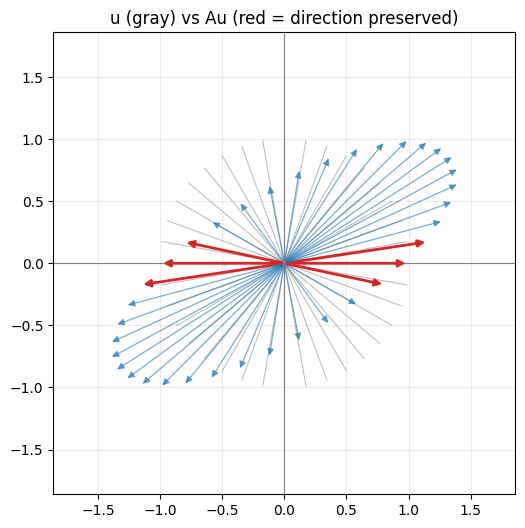

In [12]:
# The shear matrix: eigenvalue 1 twice, but only ONE eigenvector direction.
S_shear = np.array([[1.0, 1.0],
                    [0.0, 1.0]])
w_s, V_s = np.linalg.eig(S_shear)
print("eigenvalues:", w_s)
print("eigenvectors (columns):\n", V_s)   # both columns are (nearly) parallel
plotting.plot_direction_field(S_shear)
plt.show()

**(2) 回転には実固有ベクトルがない。**
90° 回転はすべての方向を変えるので、実数の範囲に固有ベクトルは存在しません。
固有値は複素数 $\pm i$ になります。複素固有値は「回転成分」の信号です。

In [13]:
# Rotation by 90 degrees: complex eigenvalues +-i, no real eigendirection.
R90 = np.array([[0.0, -1.0],
                [1.0,  0.0]])
print("eigenvalues of R90:", np.linalg.eigvals(R90))

eigenvalues of R90: [0.+1.j 0.-1.j]


**(3) 数値的な落とし穴。** 非対称行列の固有値は摂動に敏感なことがあります。
対称行列なら固有値は実数で安定、専用の `np.linalg.eigh` を使うべきです(05 章・06 章)。

## 9. Application — 安定性とフィボナッチ

**力学系の安定性。** $x_{k+1} = A x_k$ で記述されるシステム(人口、在庫、景気モデル、
ニューラルネットの勾配伝播)は、固有値の絶対値がすべて 1 未満なら 0 に収束(安定)、
1 を超える固有値があれば発散します。**スペクトル半径** $\max_i |\lambda_i|$ が運命を決めます。

**フィボナッチ数列の一般項。** $F_{k+1} = F_k + F_{k-1}$ は行列で書けます:

$$
\begin{pmatrix} F_{k+1} \\ F_k \end{pmatrix}
=
\begin{pmatrix} 1 & 1 \\ 1 & 0 \end{pmatrix}
\begin{pmatrix} F_k \\ F_{k-1} \end{pmatrix}
$$

固有値は黄金比 $\varphi = (1+\sqrt 5)/2$ と $\psi = (1-\sqrt 5)/2$。
対角化すると有名な閉じた式(Binet の公式)が得られます。

In [14]:
# Fibonacci via diagonalization: F_k grows like phi^k.
F = np.array([[1.0, 1.0],
              [1.0, 0.0]])
w_f, V_f = np.linalg.eig(F)
print("eigenvalues:", w_f, " (golden ratio phi and psi)")

# Binet-style formula from the eigendecomposition.
k = np.arange(1, 11)
D_k = np.array([V_f @ np.diag(w_f**n) @ np.linalg.inv(V_f) for n in k])
fib_from_eig = D_k[:, 0, 1]          # the (0,1) entry of F^k is F_k
print("F_1..F_10 via eigen:", np.round(fib_from_eig).astype(int))

eigenvalues: [ 1.618 -0.618]  (golden ratio phi and psi)
F_1..F_10 via eigen: [ 1  1  2  3  5  8 13 21 34 55]


```{admonition} 実社会では
:class: important
固有値・固有ベクトルは「繰り返し・振動・長期挙動」が現れるところに必ず顔を出します。

- 検索・推薦：PageRank は遷移行列の $\lambda=1$ 固有ベクトル（07 章）。
- データ圧縮：PCA は共分散行列の固有ベクトル＝分散最大の軸（05 章）。
- 工学：橋や建物の**固有振動数**、制御系の安定性（極＝固有値）。
- 物理・量子：エネルギー準位は Hamiltonian の固有値（07 章）。
- 深層学習：勾配が層を伝わるときの増幅率もスペクトル半径で決まる（勾配爆発／消失）。

「何度も掛ける」「揺れる」「収束するか発散するか」を問うた瞬間、答えは固有値の中にあります。
```

## 10. Exercises

1. $A = \begin{pmatrix} 3 & 0 \\ 0 & 0.5 \end{pmatrix}$ の固有値・固有ベクトルを手で求め、
   `plot_direction_field` で確認せよ。
2. $A = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}$ の特性方程式を手で解き、
   `np.linalg.eig` と一致することを確かめよ。
3. 移住行列の例で、初期値 $(50, 50)$ から 10 年分の軌道を固有ベクトル成分に分解し、
   $\lambda = 0.7$ 成分が毎年 0.7 倍になっていることを数値で確認せよ。
4. $\begin{pmatrix} 0 & 1 \\ -1 & 0 \end{pmatrix}$(-90° 回転)の固有値を計算し、
   実固有ベクトルが無いことを確認せよ。
5. スペクトル半径が 1 を少し超える行列(例: 固有値 1.05 と 0.5)を作り、
   $x_{k+1} = Ax_k$ の軌道が発散する様子をプロットせよ。
6. (発展)$F^k$ の計算を「素朴な行列累乗」と「対角化経由」で時間計測し、比較せよ。

## 11. Advanced Notes

**相似不変性の証明。** $\det(P^{-1}AP - \lambda I) = \det(P^{-1}(A - \lambda I)P)
= \det P^{-1} \det(A - \lambda I)\det P = \det(A - \lambda I)$。
特性多項式そのものが不変なので、固有値・det・trace すべて不変。

**対角化可能性の判定。** 固有値 $\lambda$ の「代数的重複度」(特性多項式の根としての重複度)と
「幾何的重複度」($\dim \mathrm{Ker}(A - \lambda I)$)がすべての固有値で一致することが
対角化可能の必要十分条件。せん断は代数 2・幾何 1 で不一致でした。

**Jordan 標準形。** 対角化できない行列も、対角の少し上に 1 が並ぶ
Jordan ブロックの形までは必ず簡約できます(複素数体上)。
せん断はそれ自体が $2 \times 2$ の Jordan ブロックです。

**Perron-Frobenius の定理(予告)。** 成分がすべて正の行列は、
最大固有値が正の単純固有値で、対応する固有ベクトルも成分がすべて正に取れます。
移住行列の「収束先の人口比が正で一意」だったのはこの定理の帰結で、
07 章の Markov 連鎖・PageRank の理論的支柱になります。

**対称行列の予告。** $A^\top = A$ のときは必ず実固有値を持ち、固有ベクトルを直交に取れます
(スペクトル定理、05 章)。「対称なら何も壊れない」と覚えておくと見通しが良くなります。